# MA124 Maths by Computer: Assignment 4

## Machine Learning Applied to Bike Sharing Demand Data 

Student number: u2012113

In a recent research article published in the journal Computer Communications, authors Sathishkumar V E, Jangwoo Park, and Yongyun Cho sought to prediction the "bike count required at each hour for the stable supply of rental bikes"[1]. They employed a number of regression models, including linear regression. The dataset used in the original study is available [here](https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand).


[1] Sathishkumar V E, Jangwoo Park, and Yongyun Cho. 'Using data mining techniques for bike sharing demand prediction in metropolitan city.' Computer Communications, Vol.153, pp.353-366, March, 2020. [web link](https://doi.org/10.1016/j.comcom.2020.02.007).


---
The following document uses a modified dataset of the original data. the categorical variables has been removed, and the dates coverted to months. Only the first six months are included.

---

As the original article points out, many urban cities have a growing demand in rental bike service. Hence, it is important to provide a stable supply and predict the bike count required at each hour. This paper discusses models for hourly and monthly rental bike demand prediction. Two regression models are trained: linear regression and tree regression, and their performance is evaluated using a testing set. 

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor

Although in this paper we are only going to focus on rented bike counts depending on the month and hour, the original article also focuses in many other independent variables as shown below.

In [2]:
# read the SeoulBikeData_mod.csv file into datafram SBD

SBD = pd.read_csv("SeoulBikeData_mod.csv")
SBD.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Month
count,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000,4220.000000
mean,665.802607,11.522512,9.476967,54.729147,1.883886,1342.977725,-0.066256,0.606507,0.097275,0.061280,3.492417
std,652.252686,6.930339,11.186973,20.994968,1.084647,622.576774,12.440532,0.910329,0.962272,0.348964,1.723804
min,20.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,1.000000
25%,177.000000,6.000000,1.100000,38.000000,1.000000,770.750000,-9.800000,0.000000,0.000000,0.000000,2.000000
50%,397.000000,12.000000,10.000000,53.000000,1.700000,1495.000000,0.600000,0.020000,0.000000,0.000000,3.000000
75%,1020.250000,18.000000,19.100000,70.000000,2.600000,1972.000000,10.425000,0.992500,0.000000,0.000000,5.000000
max,3556.000000,23.000000,32.700000,98.000000,7.400000,2000.000000,24.100000,3.520000,35.000000,4.100000,6.000000


The figure below shows a boxplot and histogram of the data. The histogram plot shows the frequency of rented bike count. As can be seen, the most frequent count is between 0 and 500. The boxplot displays the position of the median value in the line. There is a long tail in the data distribution. 

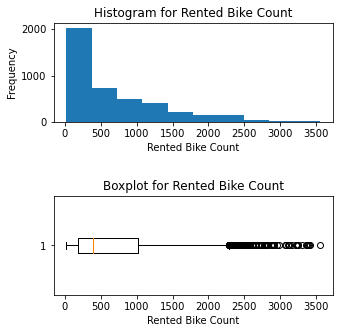

In [3]:
# --- Plot histogram of Rented Bikes --- #
test_series = SBD['Rented Bike Count']
# histogram rented bikes
fig,axs=plt.subplots(2,1,figsize = (5,5))
axs[0].hist(test_series, density=False)

# boxplot rented bikes
axs[1].boxplot(x = 'Rented Bike Count', data = SBD, vert = False)

# labels, titles
axs[0].set_xlabel("Rented Bike Count", fontsize=10)
axs[0].set_ylabel("Frequency", fontsize=10)
axs[0].title.set_text("Histogram for Rented Bike Count")
axs[1].set_xlabel("Rented Bike Count", fontsize=10)
axs[1].title.set_text("Boxplot for Rented Bike Count")
plt.subplots_adjust(hspace=0.75)
plt.show()
print()
print()


The figure below shows violin plots of the rented bikes count by month and by hour. Three lines are plotted to represent the median value, the first and third quartile. 


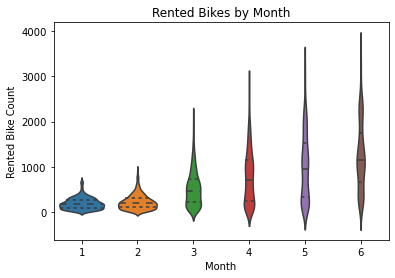

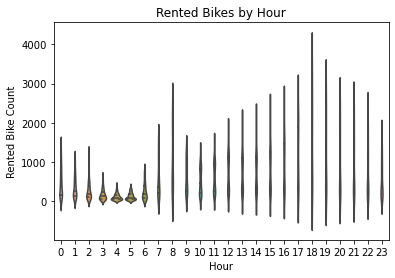

In [4]:

# --- Violin Plots Rented Bikes --- #

# By month
sns.violinplot(x='Month', y='Rented Bike Count', data=SBD, inner='quartile')
plt.title('Rented Bikes by Month')
plt.show()

# By hour
sns.violinplot(x='Hour', y='Rented Bike Count', data=SBD, inner='quartile')
plt.title('Rented Bikes by Hour')
plt.show()

The rental bike data is divided into two sets: the training set, for building the regression and the testing set, for assessing the model performance. In this case, we are going to  use the same percentage of data for testing and training as was used in Ref. [1], which is 75% for training and 25% for testing. The code splits the data into training and testing sets, trains a linear regression model and uses the model to predict the test data. To evaluate the performance, the residual is computed. Then we look at the four performance metrics. These are scalar measures of how well `y_test` and `y_pred` agree.

In [5]:
# --- Training a model --- #

# create design matrix and target
X = SBD.drop(['Rented Bike Count'], axis=1)
y = SBD['Rented Bike Count']

# split targets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the train data
regr.fit(X_train, y_train)

# Use the model to predict the test data
y_pred = regr.predict(X_test)

# residual (difference between exact values and approximate)
resid = y_test - y_pred

# --- Performance Metrics --- #

# computes root mean squared error (RMSE)
RMSE = np.sqrt(np.mean(resid**2))
print('The Root Mean Squared is ' + str(RMSE))

# computes mean absolute error (MAE)
MAE = np.mean(np.abs(resid))
print('The Mean Absolute Error is ' + str(MAE))

# R^2 coefficient of determination
R2 = r2_score(y_test, y_pred)
print('The coefficient of determination (R^2) is ' + str(R2))


The Root Mean Squared is 401.6743365903192
The Mean Absolute Error is 296.2217587853785
The coefficient of determination (R^2) is 0.6213353685180052


The following plots show how well the linear regression model performs. The first figure shows the residuals as a function of rented bikes count and each point is coloured according to its corresponding month. The second figure plots two histograms of the exact data and the approximate data predicted by the regression model. The third and fourth plots show the residuals as functions of month and hour respectively. The blue points represent the absolute values of the residuals and the red points all the residuals (although only the negative can be seen due to the positive overlapping with the blue points). The more points near 0, the better the model is.

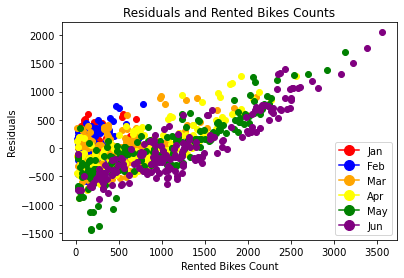

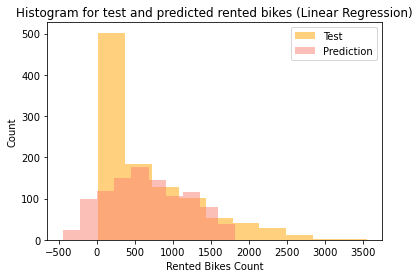

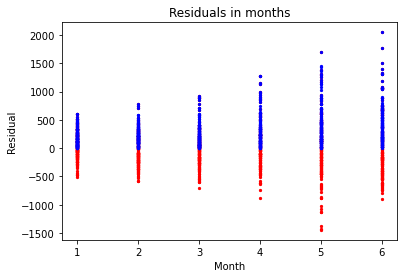

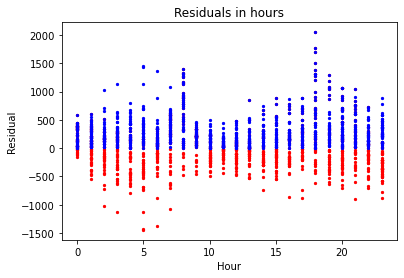

In [6]:
# --- Plots of performance --- #

# creates arrays of the data
rented_bikes_test = np.array(y_test)
res = np.array(resid)
key = np.array(X_test['Month'])
N = X_test.shape

# colormap for the different months
l = ['red','blue','orange','yellow','green','purple']

# plots rented bikes and residuals by months
j=1
while j<=6:
    for i in range (0,N[0]):
        if key[i] == j:
            p = rented_bikes_test[i]
            q = res[i]
            plt.scatter(p,q,c = l[j-1])
    j = j+1
# legend, labels, titles
lines = [Line2D([0], [0], color=c, markersize = 10, marker = 'o') for c in l]
labels = ['Jan', 'Feb', 'Mar','Apr','May','Jun']
plt.legend(lines, labels, loc = 'lower right')
plt.title('Residuals and Rented Bikes Counts')
plt.xlabel('Rented Bikes Count')
plt.ylabel('Residuals')
plt.show()

# --- Histogram exact and predicted values of rented bikes --- # 
plt.hist(y_test,density = False, label = 'Test', alpha = 0.5, color = 'orange')
plt.hist(y_pred, density = False, label= 'Prediction', alpha = 0.5, color = 'salmon')
# labels, titles
plt.title('Histogram for test and predicted rented bikes (Linear Regression)')
plt.xlabel('Rented Bikes Count')
plt.ylabel('Count')
plt.legend()
plt.show()

# --- Residuals plots--- # 

# creates array with the abs values of residuals
for i in range (0,N[0]):
    res[i]= abs(res[i])
    
# plots residuals in months and its absolute value    
plt.scatter(X_test['Month'],resid,color= 'r', s= 5)
plt.scatter(X_test['Month'],res,color = 'b',s = 5)
# labels, titles 
plt.xlabel('Month')
plt.ylabel('Residual')
plt.title('Residuals in months')
plt.show()

# plots residuals in months and its absolute value 
plt.scatter(X_test['Hour'],resid,color= 'r', s= 5)
plt.scatter(X_test['Hour'],res,color = 'b',s = 5)
plt.xlabel('Hour')
plt.ylabel('Residual')
plt.title('Residuals in hours')
plt.show()




Another regression, decision tree regression, is created to evaluate and predicted the rented bikes count in each month and hour of day. The training set is used to train the model and the test set is used to predict the result. As the performance metrics show, this model is more accurate than the previous one. The figure shows two histograms of the exact count of rented bikes and the predicted using this model.

The Root Mean Squared is 288.46175692642186
The Mean Absolute Error is 183.72851765699525
The coefficient of determination (R^2) is 0.8047086259832199



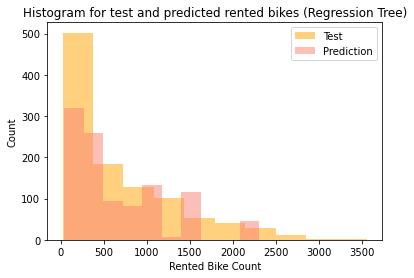

In [7]:
# --- Regression Trees--- #

# fit regression model
regr_1 = DecisionTreeRegressor(max_depth=6)
regr_1.fit(X_train, y_train)

# predict
y1_pred = regr_1.predict(X_test)

resid_1 = y_test - y1_pred


# --- Performance Metrics --- #

# computes root mean squared error (RMSE)
RMSE = np.sqrt(np.mean(resid_1**2))
print('The Root Mean Squared is ' + str(RMSE))

# computes mean absolute error (MAE)
MAE = np.mean(np.abs(resid_1))
print('The Mean Absolute Error is ' + str(MAE))

# R^2 coefficient of determination
R2 = r2_score(y_test, y1_pred)
print('The coefficient of determination (R^2) is ' + str(R2))
print()
# plot results
plt.hist(y_test,density = False, label = 'Test', alpha = 0.5, color = 'orange')
plt.hist(y1_pred, density = False, label= 'Prediction', alpha = 0.5, color = 'salmon')

#labels,titles etc
plt.xlabel('Rented Bike Count')
plt.ylabel('Count')
plt.title('Histogram for test and predicted rented bikes (Regression Tree)')
plt.legend()
plt.show()

After evaluating the efficiency of each regression we can conclude that the regression tree has greater predictive outcomes than the linear regression since the value of R^2 is higher. We also have lot of data to analyze when are the peak months and peak hours of rented bikes as well as when the demand is not so high. In the article, more regression models were trained, and within those, the linear regression produces the worst results too. Therefore, we can conclude that rented bikes count is not linearly related to months and hours. 